# 🏭 Variational Autoencoders (VAEs) in Chemical Process Monitoring
### Industrial Automation — Chemical Engineering Domain

---

> **Audience:** Process engineers, automation specialists, and data scientists working in chemical manufacturing.

This notebook covers:
1. What VAEs are — in plain language
2. The Artificial Neural Network (ANN) backbone inside a VAE
3. Pros & cons for industrial use
4. Best use case: **Anomaly detection in a continuous chemical reactor**
5. A worked simulation with synthetic process data

---

## 1. What is a Variational Autoencoder?

Imagine your chemical plant produces **thousands of sensor readings per minute** — temperature, pressure, flow rate, pH, viscosity. Most of the time the process is *normal*, but occasionally something drifts. How do you automatically detect that drift?

A **Variational Autoencoder (VAE)** learns to **compress** normal operating data into a compact mathematical summary (the *latent space*), and then **reconstruct** it back. If a new reading cannot be reconstructed well, the process is likely in an abnormal state.

```
RAW SENSOR DATA  →  [ENCODER ANN]  →  LATENT SPACE  →  [DECODER ANN]  →  RECONSTRUCTED DATA
    (high-dim)           ↓                (low-dim)           ↓               (high-dim)
                   Compresses              μ, σ            Expands          Compare to input
                   information           (mean,std)       information       → Reconstruction
                                                                               Error = Anomaly Score
```

### The 'Variational' Part
Unlike a plain autoencoder, a VAE does not encode data to a single point. It encodes to a **probability distribution** (a Gaussian described by mean μ and standard deviation σ). This makes the latent space smooth and continuous — ideal for detecting gradual process drift.

---

## 2. The ANN Backbone — How Neural Networks Power the VAE

Both the **Encoder** and **Decoder** are Artificial Neural Networks (ANNs) — stacks of layers where each neuron learns a weighted combination of its inputs.

```
ENCODER ANN                        DECODER ANN
───────────────────                ──────────────────────
Input Layer  (n sensors)           Latent vector z  (sampled)
     ↓                                    ↓
Hidden Layer 1  (Dense + ReLU)     Hidden Layer 1  (Dense + ReLU)
     ↓                                    ↓
Hidden Layer 2  (Dense + ReLU)     Hidden Layer 2  (Dense + ReLU)
     ↓                                    ↓
Output: μ vector & log(σ²) vector  Output Layer  (n sensors, linear)
```

**Key ANN concepts used:**
- **Dense (fully connected) layers** — every neuron connects to every neuron in the next layer
- **ReLU activation** — allows the network to model non-linear chemical relationships
- **Reparameterisation trick** — allows gradients to flow through the random sampling step during training
- **Loss function** = Reconstruction Loss + KL Divergence (keeps latent space well-organised)

---

## 3. Pros & Cons for Industrial / Chemical Engineering Applications

| | Detail |
|---|---|
| ✅ **Unsupervised** | No need to label thousands of hours of normal vs fault data |
| ✅ **Handles high-dimensional sensor arrays** | Dozens of process variables compressed efficiently |
| ✅ **Anomaly score is continuous** | Provides severity, not just a binary alarm |
| ✅ **Probabilistic latent space** | Can model process uncertainty and noise natively |
| ✅ **Smooth interpolation** | Useful for soft-sensor prediction and missing-data imputation |
| ❌ **Needs lots of normal data** | Requires substantial historical data from stable operation |
| ❌ **Hyperparameter tuning** | Latent dimension, layer sizes, β weighting need engineering judgment |
| ❌ **Black-box interpretability** | Difficult to explain *why* a reading is anomalous to operators |
| ❌ **Retraining needed after process changes** | Significant plant modifications may invalidate the model |
| ❌ **Computationally heavier than PCA** | Though feasible on modern PLCs or edge servers |

---

## 4. Best Use Case: Anomaly Detection in a Continuous Stirred Tank Reactor (CSTR)

A CSTR has multiple interacting variables (feed flow, jacket temperature, agitator speed, outlet composition). Faults — fouling, heat exchanger blockage, catalyst deactivation — often manifest as **subtle multi-variable deviations** that single-variable alarms miss.

A VAE trained on normal operation data will assign a **high reconstruction error** to any reading pattern it has never seen before — providing an early warning long before traditional trip thresholds are breached.

**Other strong use cases in chemical engineering:**
- Distillation column flooding prediction
- Compressor surge detection
- Batch fermentation end-point prediction
- Soft sensor for composition when analysers are offline

---

## 5. Hands-On: VAE for CSTR Anomaly Detection

We will:
1. Simulate normal CSTR sensor data
2. Build and train a VAE using PyTorch
3. Introduce a simulated fault (heat exchanger fouling)
4. Show the VAE detects the fault via elevated reconstruction error

In [1]:
# Install dependencies (run once)
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch', 'numpy', 'matplotlib', 'scikit-learn', '--quiet'])
print('Dependencies ready.')

Dependencies ready.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

print('Libraries imported successfully.')

Libraries imported successfully.


### 5.1 Simulate CSTR Sensor Data

We simulate 7 process variables measured every minute:
- `T_reactor` — Reactor temperature (°C)
- `T_jacket` — Cooling jacket temperature (°C)
- `F_feed` — Feed flow rate (L/min)
- `P_reactor` — Reactor pressure (bar)
- `pH` — pH of reactor contents
- `agitator_rpm` — Agitator speed
- `outlet_conc` — Outlet product concentration (mol/L)

Normal data shape : (2000, 7)  (samples × process variables)
Fault data shape  : (400, 7)


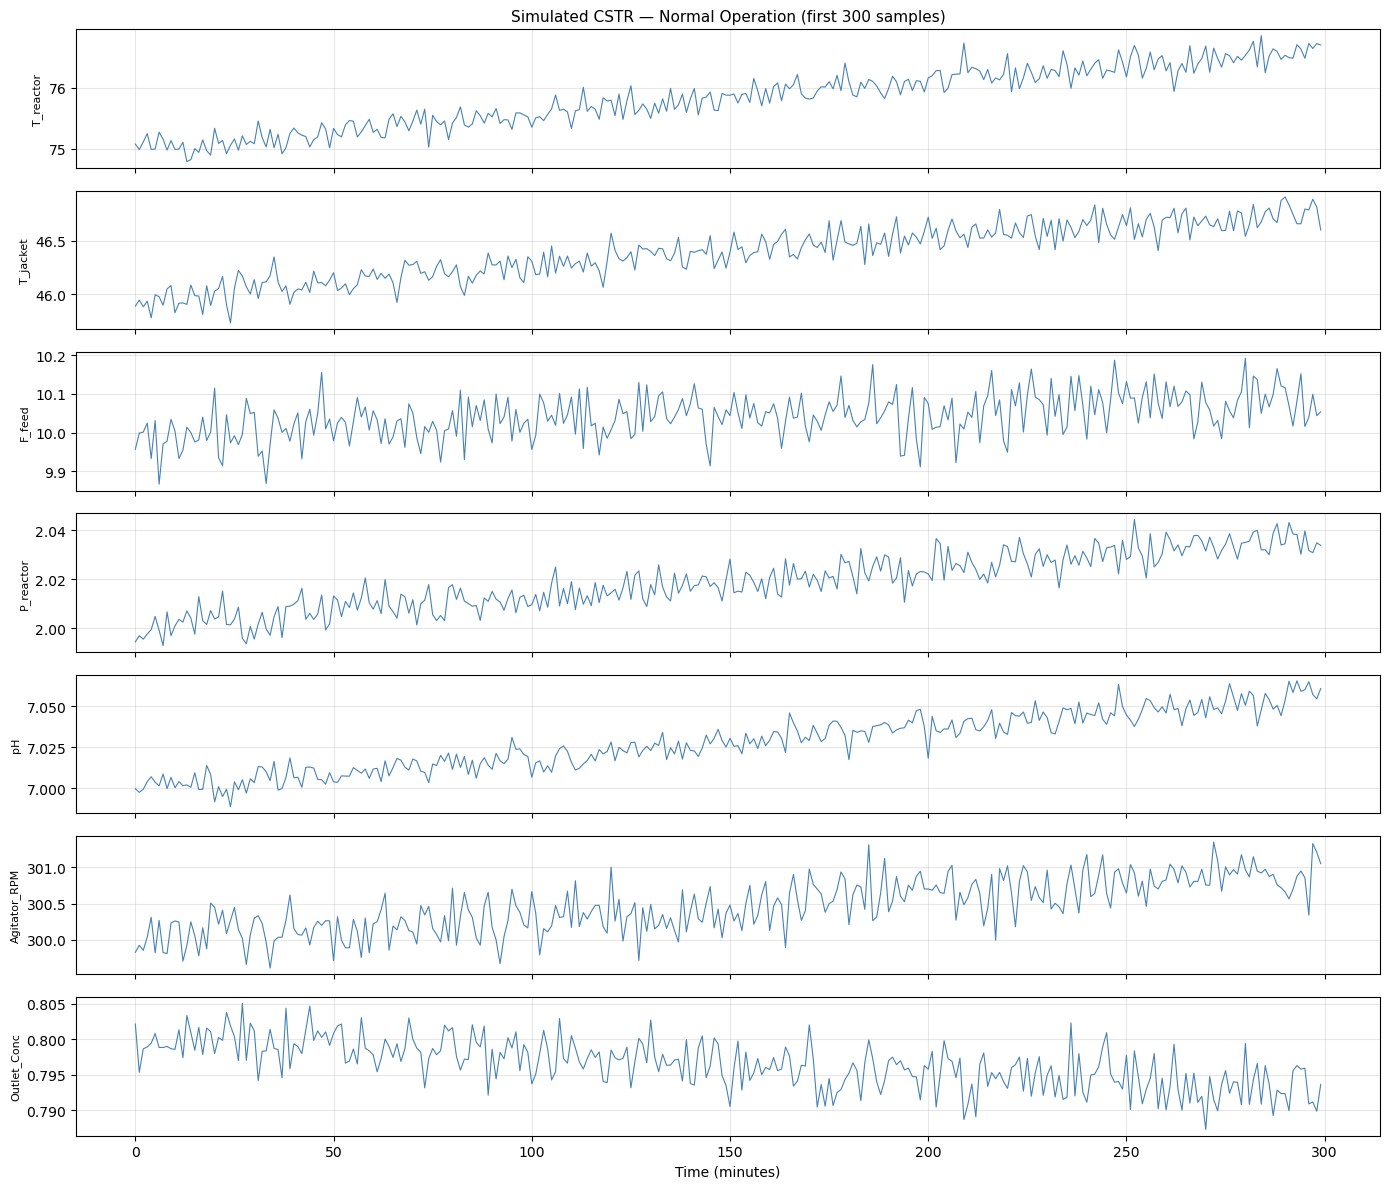

In [3]:
def simulate_cstr_normal(n_samples=2000, noise=0.05):
    """Simulate correlated normal CSTR operation."""
    t = np.linspace(0, 4 * np.pi, n_samples)

    T_reactor   = 75 + 3 * np.sin(t * 0.3) + np.random.normal(0, noise * 3, n_samples)
    T_jacket    = 45 + 2 * np.sin(t * 0.3 + 0.5) + np.random.normal(0, noise * 2, n_samples)
    F_feed      = 10 + 0.5 * np.sin(t * 0.1) + np.random.normal(0, noise, n_samples)
    P_reactor   = 2.0 + 0.1 * np.sin(t * 0.2) + np.random.normal(0, noise * 0.1, n_samples)
    pH          = 7.0 + 0.2 * np.sin(t * 0.15) + np.random.normal(0, noise * 0.1, n_samples)
    agitator    = 300 + 10 * np.sin(t * 0.05) + np.random.normal(0, noise * 5, n_samples)
    # Outlet concentration is correlated with T_reactor and F_feed
    outlet_conc = 0.8 - 0.005 * (T_reactor - 75) + 0.01 * (F_feed - 10) + np.random.normal(0, noise * 0.05, n_samples)

    return np.column_stack([T_reactor, T_jacket, F_feed, P_reactor, pH, agitator, outlet_conc])


def simulate_cstr_fault(n_samples=400, fault_type='heat_exchanger_fouling'):
    """Simulate faulty operation. Heat exchanger fouling: jacket temperature drifts up."""
    base = simulate_cstr_normal(n_samples, noise=0.05)
    if fault_type == 'heat_exchanger_fouling':
        drift = np.linspace(0, 12, n_samples)  # Progressive jacket temp rise
        base[:, 1] += drift                     # T_jacket column
        base[:, 0] += drift * 0.6               # T_reactor also rises
        base[:, 6] -= drift * 0.003             # outlet_conc drops slightly
    return base


X_normal = simulate_cstr_normal(2000)
X_fault  = simulate_cstr_fault(400)

print(f'Normal data shape : {X_normal.shape}  (samples × process variables)')
print(f'Fault data shape  : {X_fault.shape}')

SENSOR_NAMES = ['T_reactor', 'T_jacket', 'F_feed', 'P_reactor', 'pH', 'Agitator_RPM', 'Outlet_Conc']

fig, axes = plt.subplots(7, 1, figsize=(14, 12), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(X_normal[:300, i], color='steelblue', label='Normal', linewidth=0.8)
    ax.set_ylabel(SENSOR_NAMES[i], fontsize=8)
    ax.grid(True, alpha=0.3)
axes[0].set_title('Simulated CSTR — Normal Operation (first 300 samples)', fontsize=11)
axes[-1].set_xlabel('Time (minutes)')
plt.tight_layout()
plt.show()

### 5.2 Build the VAE (ANN Architecture)

In [4]:
class Encoder(nn.Module):
    """
    ANN Encoder: maps high-dimensional sensor readings → latent distribution (μ, log σ²).
    Architecture: Dense(7→32) → ReLU → Dense(32→16) → ReLU → two parallel heads for μ and log_var
    """
    def __init__(self, input_dim=7, hidden_dim=32, latent_dim=3):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, 16),        nn.ReLU()
        )
        self.fc_mu      = nn.Linear(16, latent_dim)
        self.fc_log_var = nn.Linear(16, latent_dim)

    def forward(self, x):
        h = self.shared(x)
        return self.fc_mu(h), self.fc_log_var(h)


class Decoder(nn.Module):
    """
    ANN Decoder: maps latent vector z → reconstructed sensor readings.
    Architecture: Dense(3→16) → ReLU → Dense(16→32) → ReLU → Dense(32→7)
    """
    def __init__(self, latent_dim=3, hidden_dim=32, output_dim=7):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 16),  nn.ReLU(),
            nn.Linear(16, hidden_dim),  nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, z):
        return self.net(z)


class VAE(nn.Module):
    """
    Complete VAE: Encoder + Reparameterisation + Decoder
    """
    def __init__(self, input_dim=7, hidden_dim=32, latent_dim=3):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def reparameterise(self, mu, log_var):
        """Reparameterisation trick: z = μ + σ * ε,  ε ~ N(0,I)"""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z           = self.reparameterise(mu, log_var)
        x_hat       = self.decoder(z)
        return x_hat, mu, log_var


def vae_loss(x, x_hat, mu, log_var, beta=1.0):
    """
    VAE loss = Reconstruction loss (MSE) + β * KL Divergence
    KL term keeps the latent space well-organised (close to N(0,I)).
    β > 1 encourages a more disentangled latent space.
    """
    recon_loss = nn.functional.mse_loss(x_hat, x, reduction='sum')
    kl_loss    = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + beta * kl_loss


vae = VAE(input_dim=7, hidden_dim=32, latent_dim=3)
total_params = sum(p.numel() for p in vae.parameters())
print(vae)
print(f'\nTotal trainable parameters: {total_params:,}')

VAE(
  (encoder): Encoder(
    (shared): Sequential(
      (0): Linear(in_features=7, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=16, bias=True)
      (3): ReLU()
    )
    (fc_mu): Linear(in_features=16, out_features=3, bias=True)
    (fc_log_var): Linear(in_features=16, out_features=3, bias=True)
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): Linear(in_features=3, out_features=16, bias=True)
      (1): ReLU()
      (2): Linear(in_features=16, out_features=32, bias=True)
      (3): ReLU()
      (4): Linear(in_features=32, out_features=7, bias=True)
    )
  )
)

Total trainable parameters: 1,725


### 5.3 Preprocess Data & Train

Epoch  10/80  |  Avg Loss: 2.0299
Epoch  20/80  |  Avg Loss: 1.6005
Epoch  30/80  |  Avg Loss: 1.4563
Epoch  40/80  |  Avg Loss: 1.4492
Epoch  50/80  |  Avg Loss: 1.4487
Epoch  60/80  |  Avg Loss: 1.4408
Epoch  70/80  |  Avg Loss: 1.4415
Epoch  80/80  |  Avg Loss: 1.4276


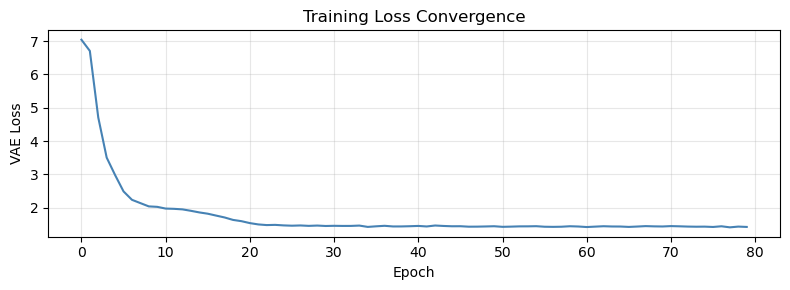

In [5]:
# Standardise: subtract mean, divide by std — critical for stable ANN training
scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_normal)
X_fault_np = scaler.transform(X_fault)

X_train = torch.tensor(X_train_np, dtype=torch.float32)
X_fault_t = torch.tensor(X_fault_np, dtype=torch.float32)

loader = DataLoader(TensorDataset(X_train), batch_size=64, shuffle=True)

# --- Training loop ---
optimizer = optim.Adam(vae.parameters(), lr=1e-3)
EPOCHS = 80
losses = []

vae.train()
for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    for (batch,) in loader:
        optimizer.zero_grad()
        x_hat, mu, log_var = vae(batch)
        loss = vae_loss(batch, x_hat, mu, log_var, beta=0.5)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(X_train)
    losses.append(avg)
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS}  |  Avg Loss: {avg:.4f}')

plt.figure(figsize=(8, 3))
plt.plot(losses, color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('VAE Loss')
plt.title('Training Loss Convergence')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 Anomaly Detection — Reconstruction Error as Fault Score

Alarm threshold (99th pct of normal): 0.3217
Mean error — Normal  : 0.0761
Mean error — Fault   : 4.1674
Fault samples above threshold: 358 / 400


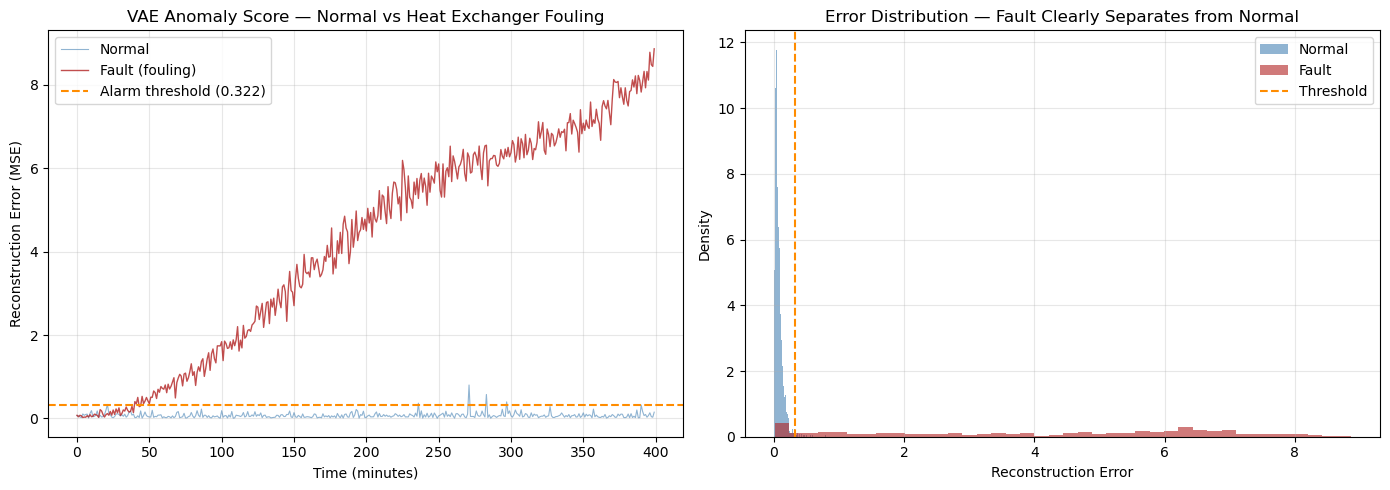

In [6]:
vae.eval()

def reconstruction_error(model, X_tensor):
    """Per-sample MSE between input and VAE reconstruction."""
    with torch.no_grad():
        x_hat, _, _ = model(X_tensor)
        errors = ((X_tensor - x_hat) ** 2).mean(dim=1).numpy()
    return errors


errors_normal = reconstruction_error(vae, X_train)
errors_fault  = reconstruction_error(vae, X_fault_t)

# Set alarm threshold at 99th percentile of normal operation
threshold = np.percentile(errors_normal, 99)
print(f'Alarm threshold (99th pct of normal): {threshold:.4f}')
print(f'Mean error — Normal  : {errors_normal.mean():.4f}')
print(f'Mean error — Fault   : {errors_fault.mean():.4f}')
print(f'Fault samples above threshold: {(errors_fault > threshold).sum()} / {len(errors_fault)}')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time-series of reconstruction error
ax = axes[0]
ax.plot(errors_normal[:400], color='steelblue', alpha=0.6, label='Normal', linewidth=0.8)
ax.plot(range(400), errors_fault, color='firebrick', alpha=0.8, label='Fault (fouling)', linewidth=1.0)
ax.axhline(threshold, color='darkorange', linestyle='--', linewidth=1.5, label=f'Alarm threshold ({threshold:.3f})')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Reconstruction Error (MSE)')
ax.set_title('VAE Anomaly Score — Normal vs Heat Exchanger Fouling')
ax.legend()
ax.grid(True, alpha=0.3)

# Distribution of errors
ax2 = axes[1]
ax2.hist(errors_normal, bins=60, alpha=0.6, color='steelblue', label='Normal', density=True)
ax2.hist(errors_fault,  bins=40, alpha=0.6, color='firebrick',  label='Fault', density=True)
ax2.axvline(threshold, color='darkorange', linestyle='--', linewidth=1.5, label='Threshold')
ax2.set_xlabel('Reconstruction Error')
ax2.set_ylabel('Density')
ax2.set_title('Error Distribution — Fault Clearly Separates from Normal')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.5 Visualise the Latent Space

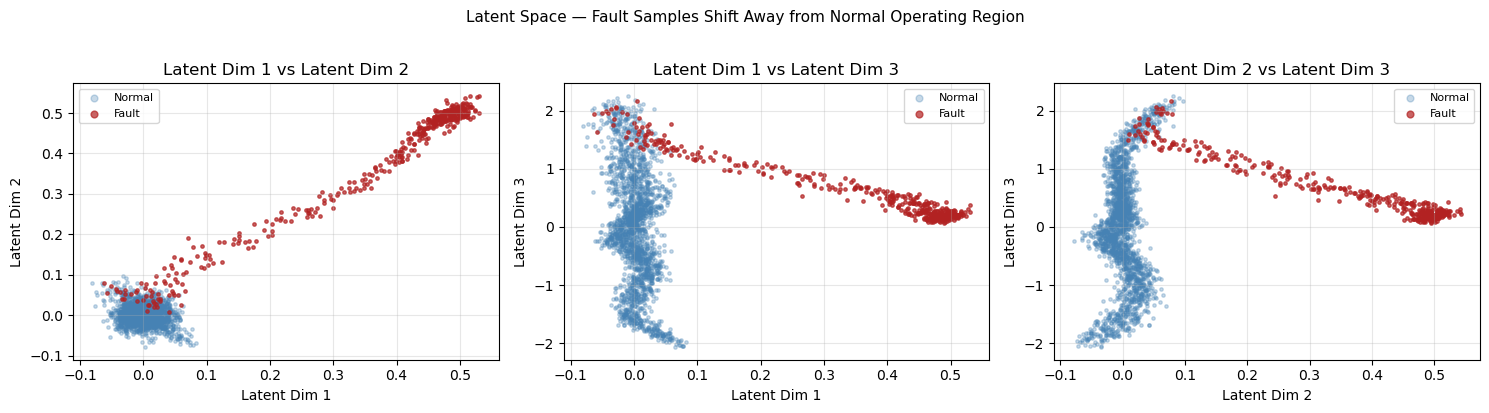

In [7]:
vae.eval()
with torch.no_grad():
    mu_normal, _ = vae.encoder(X_train)
    mu_fault,  _ = vae.encoder(X_fault_t)

mu_n = mu_normal.numpy()
mu_f = mu_fault.numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [(0, 1), (0, 2), (1, 2)]
labels = ['Latent Dim 1', 'Latent Dim 2', 'Latent Dim 3']

for ax, (i, j) in zip(axes, pairs):
    ax.scatter(mu_n[:, i], mu_n[:, j], s=6, alpha=0.3, color='steelblue', label='Normal')
    ax.scatter(mu_f[:, i], mu_f[:, j], s=6, alpha=0.7, color='firebrick',  label='Fault')
    ax.set_xlabel(labels[i])
    ax.set_ylabel(labels[j])
    ax.set_title(f'{labels[i]} vs {labels[j]}')
    ax.legend(markerscale=2, fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Latent Space — Fault Samples Shift Away from Normal Operating Region', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

### 5.6 Which Sensor Contributed Most to the Anomaly?

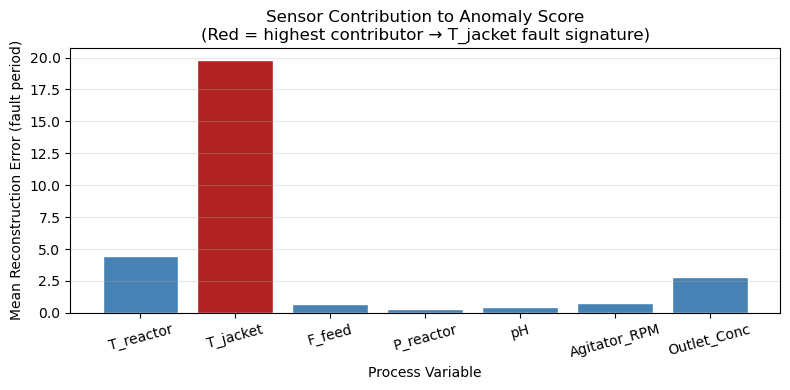

Primary fault indicator: T_jacket
This is consistent with a heat exchanger fouling event — the jacket temperature drifts anomalously.


In [8]:
vae.eval()
with torch.no_grad():
    x_hat_fault, _, _ = vae(X_fault_t)
    per_sensor_error = ((X_fault_t - x_hat_fault) ** 2).mean(dim=0).numpy()

plt.figure(figsize=(8, 4))
colours = ['firebrick' if e == per_sensor_error.max() else 'steelblue' for e in per_sensor_error]
bars = plt.bar(SENSOR_NAMES, per_sensor_error, color=colours, edgecolor='white')
plt.xlabel('Process Variable')
plt.ylabel('Mean Reconstruction Error (fault period)')
plt.title('Sensor Contribution to Anomaly Score\n(Red = highest contributor → T_jacket fault signature)')
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

top_sensor = SENSOR_NAMES[per_sensor_error.argmax()]
print(f'Primary fault indicator: {top_sensor}')
print('This is consistent with a heat exchanger fouling event — the jacket temperature drifts anomalously.')

## 6. Summary & Engineering Take-Aways

| Aspect | Finding |
|---|---|
| **Model** | 3-layer ANN Encoder + 3-layer ANN Decoder, 3D latent space |
| **Training data** | 2,000 minutes of normal CSTR operation |
| **Detection** | Fault samples clearly exceed the 99th-percentile threshold |
| **Root-cause hint** | Per-sensor error identifies T_jacket as the primary fault variable |
| **Latent space** | Fault samples occupy a distinct region — useful for process regime classification |

### Next Steps for Production Deployment
1. **Retrain on real plant historian data** (OSIsoft PI, Aspen InfoPlus.21, etc.)
2. **Sliding-window inputs** — feed the last N minutes as a sequence rather than a single snapshot
3. **Online model update** — periodically retrain as the process evolves
4. **Integration with DCS/SCADA** — expose anomaly score as a calculated tag
5. **Operator dashboard** — pair anomaly score with sensor contribution chart for root-cause guidance

---
*Notebook prepared for industrial automation use — Chemical Engineering domain.*